# Event display: diffuser vs collimator vs laser (grid-based and fit-based)

Simulates diffuser/collimator/laser events at real HK injector positions
(`UKLIinfo/LightInjectorsDetails.json`, via `hk_injector_sources.injector_sources`), plus
fit-based versions of the collimator/diffuser at the same spot, and plots each resulting
per-PMT hit pattern with the same 2D unrolled barrel+caps display used for track events.
Same PRNG key throughout, so comparisons aren't confounded by different photon-noise draws.

Both the GPU work AND the plotting happen in `event_display_job.py`, which saves PNGs
directly -- not just the raw `.npz`. Importing `lucid.visualization` here in the notebook
would cascade-import jax (it pulls in `lucid.utils`, where the jax-based helpers live) into
this long-lived kernel, and JAX grabs/inits a GPU device on first import, sticky for the
kernel's lifetime regardless of env vars set afterward -- exactly what running the GPU work
in a subprocess is supposed to avoid. So this notebook never imports `lucid` at all; it only
loads the saved PNGs and the raw arrays for reference.

In [1]:
import sys

!{sys.executable} event_display_job.py --gpu 2 --out event_display_col24.npz


[CudaDevice(id=0)]
gpu
19746 PMTs | r=32.4 m | H=65.9 m
collimator rotation-only check: rotate(1,0,0) -> [-4.371139e-08  0.000000e+00 -1.000000e+00] vs intended direction [ 0.  0. -1.] | angle apart: 0.0000 deg
diffuser rotation-only check: rotate(1,0,0) -> [-4.371139e-08  0.000000e+00 -1.000000e+00] vs intended direction [ 0.  0. -1.] | angle apart: 0.0000 deg
collimator_fit rotation-only check: rotate(1,0,0) -> [-4.371139e-08  0.000000e+00 -1.000000e+00] vs intended direction [ 0.  0. -1.] | angle apart: 0.0000 deg
diffuser_fit rotation-only check: rotate(1,0,0) -> [-4.371139e-08  0.000000e+00 -1.000000e+00] vs intended direction [ 0.  0. -1.] | angle apart: 0.0000 deg
synthetic_beam rotation-only check: rotate(1,0,0) -> [-4.371139e-08  0.000000e+00 -1.000000e+00] vs intended direction [ 0.  0. -1.] | angle apart: 0.0000 deg
collimator raw dump:
  ray_vectors  dtype=float32 shape=(5, 3) nan=0 inf=0
[[ 0.00767298  0.04583326 -0.99891967]
 [ 0.00814003  0.00141254 -0.99996585]
 [-0.032

In [2]:
import numpy as np
import matplotlib.pyplot as plt

r = np.load('event_display_results.npz', allow_pickle=True)

def show(label, log=True):
    fig = plt.figure(figsize=(9, 9))
    plt.imshow(plt.imread(f'{label}_log.png' if log else f'{label}.png'))
    plt.axis('off')
    plt.show()


## Diffuser event
Broad, diffuse hit pattern -- consistent with the wide (near-hemispheric) angular profile
`WarwickDA02` was built from.

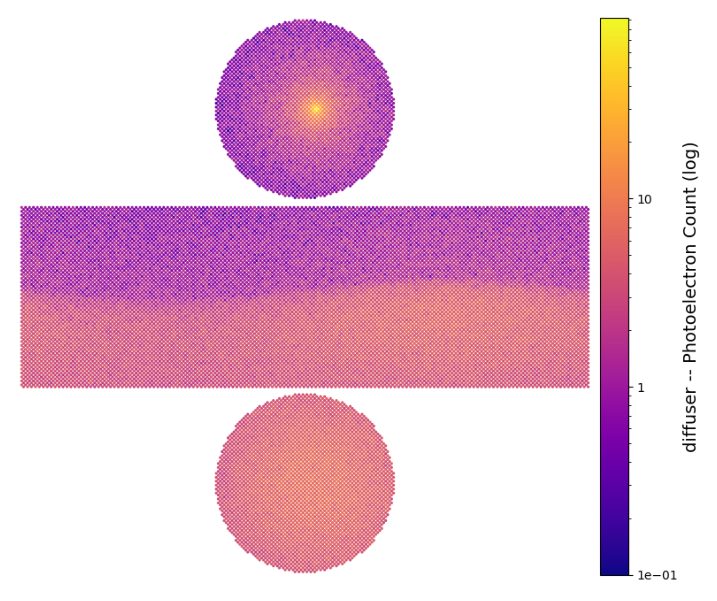

In [3]:
show('diffuser')


## Collimator event
Tight, narrow-beam hit pattern -- consistent with the few-degree-wide angular profile
`WarwickCol_C01_repeat` was built from.

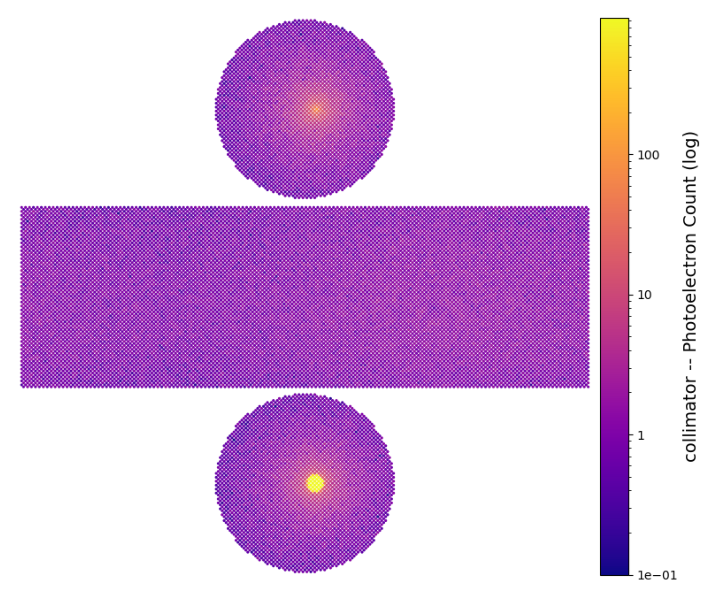

In [4]:
show('collimator')


## Laser event (same position/direction as the collimator)
Idealized `laser_source` (closed-form cone, not measured data) at the exact same spot as
the collimator above, run through the identical propagation/reflection code. If this shows
the same diffuse wash across the whole detector, that's a propagation effect (scattering/
reflection/expected-value smearing) common to any narrow beam here -- not something
specific to the measured-profile collimator's own angular sampling.

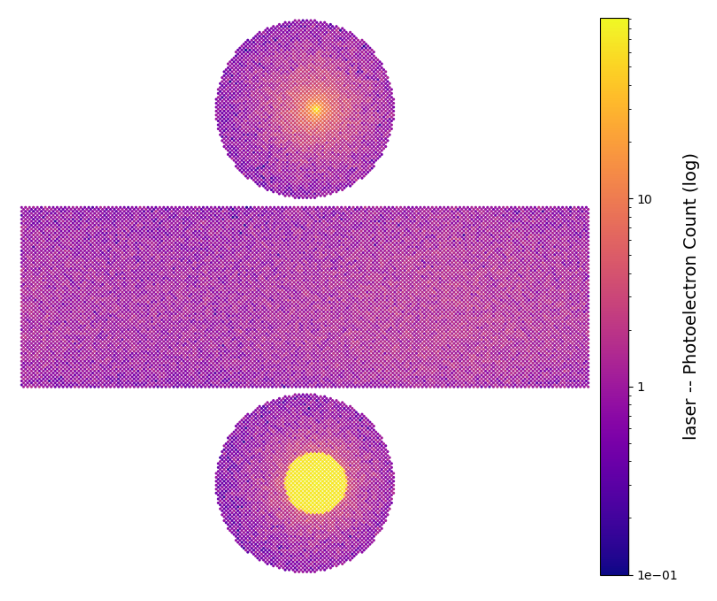

In [5]:
show('laser')


## Collimator/diffuser, fit-based, at the SAME position/direction
`fitted_profile_source` at the exact same spot as the grid-based collimator/diffuser above,
using the already-fitted `composite(w,p,a0,s)` params (`fitted_profile_source_results.npz`)
instead of the raw measured grid. Completely different CDF-table construction
(`build_fit_cdf`, an analytic function) from the grid-based one (`build_profile_cdf`,
bilinear lookup on the real scan) -- but both funnel into the same
`sample_measured_profile_rays`/rotation code afterward. If the fit-based version doesn't
show the same anomaly, that points at the grid/table construction specifically; if it does,
that points at the shared code instead.

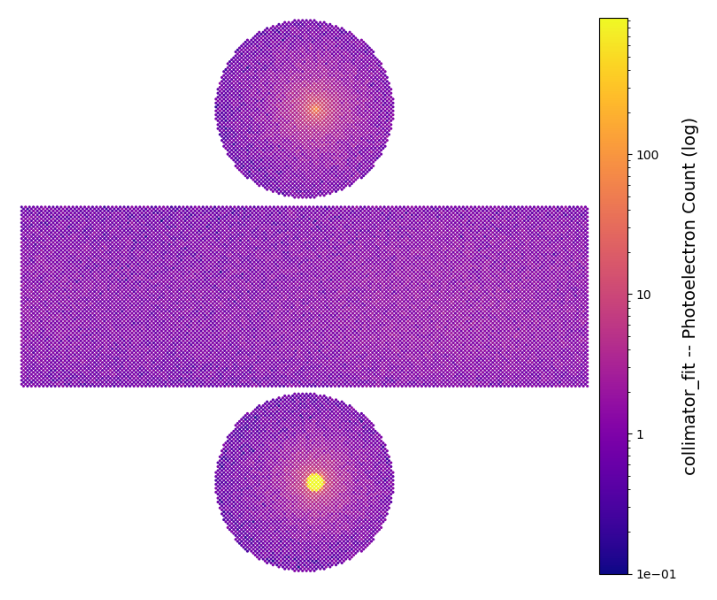

In [6]:
show('collimator_fit')


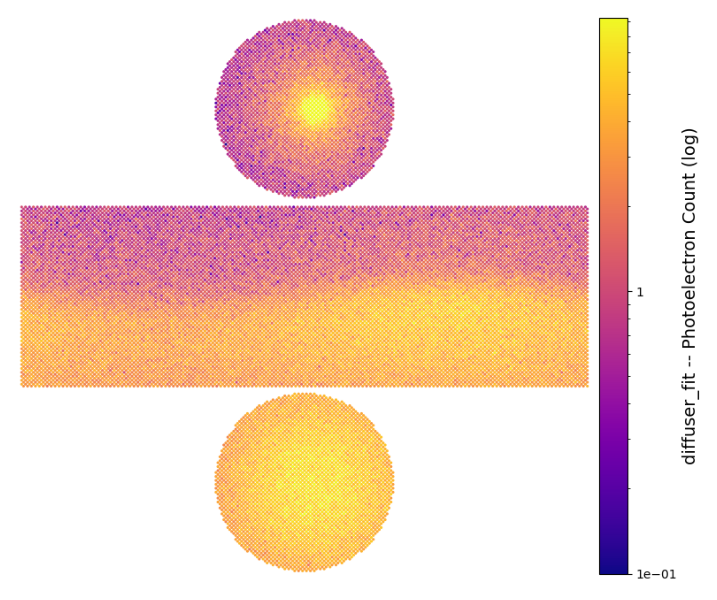

In [7]:
show('diffuser_fit')


## Synthetic forward-biased beam, same spot as collimator/laser
Hand-picked (NOT fitted to any real data) `composite(w=15, p=6, a0=9.5, s=0.3)` -- a wide/
high-power super-Gaussian core stays near-flat out past 9.5deg, then a hard (0.3deg) Fermi
edge cuts it off there, approximating the laser's ~9.5deg uniform-density hard-cutoff cone
(`arcsin(0.22/1.33)`). Still goes through `fitted_profile_source` ->
`sample_measured_profile_rays` -> the same rotation as every other `MeasuredProfileSource`
above. If this looks clean like the laser, the anomaly is shape-dependent (peaked vs
flat-top), not code-path-dependent; if it still shows the same pattern, that's a much
stronger case for something in the shared code itself.

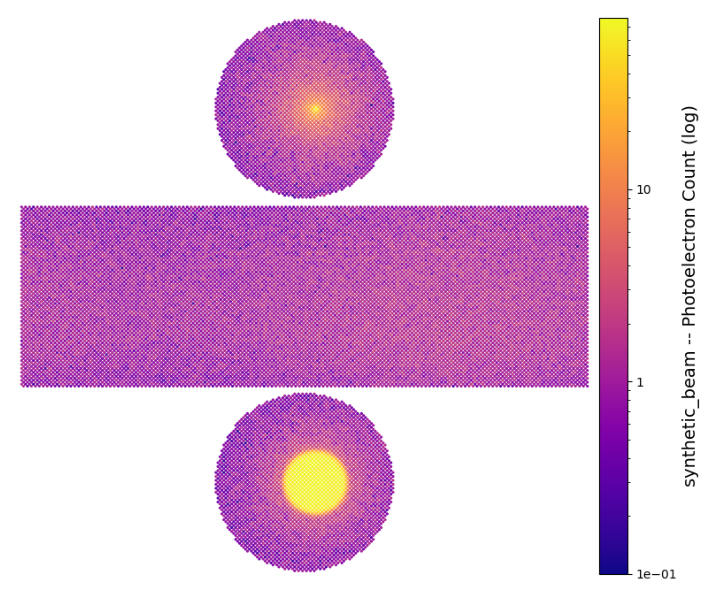

In [8]:
show('synthetic_beam')


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

r = np.load('event_display_results.npz', allow_pickle=True)
geo = np.load('../config/hk_geometry.npz')
_s = geo['surfaces']
_order = np.concatenate([np.where(_s == k)[0] for k in ('barrel', 'top', 'bottom')])
pmt = geo['positions_mm'][_order] / 1000.0
surf = _s[_order]
R, H = float(geo['radius']), float(geo['height'])


def _binned(u, v, w, pix):
    xb = np.arange(u.min(), u.max() + pix, pix)
    yb = np.arange(v.min(), v.max() + pix, pix)
    tot, _, _ = np.histogram2d(u, v, [xb, yb], weights=w)
    n, _, _ = np.histogram2d(u, v, [xb, yb])
    with np.errstate(invalid='ignore', divide='ignore'):
        img = tot / n
    return xb, yb, img.T


def show_occupancy(label, lit_occ=0.4, vmin=0.006, vmax=2.0, pix=1.5, save=None):
    # expected p.e. -> single-photon occupancy 1-exp(-s*mu), with s fixed so the
    # lit lower barrel (z < -10 m) averages lit_occ %, WCSim's level
    mu = r[f'charge_{label}'].astype(float)
    lit = (surf == 'barrel') & (pmt[:, 2] < -10)
    occ = 100 * (1 - np.exp(-mu * (lit_occ / 100) / mu[lit].mean()))

    x, y, z = pmt.T
    gap = 3.0
    panels = [
        (surf == 'top', x, y, H / 2 + gap + R),
        (surf == 'barrel', R * np.arctan2(y, x), z, 0.0),
        (surf == 'bottom', x, y, -(H / 2 + gap + R)),
    ]
    norm = LogNorm(vmin=vmin, vmax=vmax)
    fig, ax = plt.subplots(figsize=(8, 9))
    for m, u, v, dy in panels:
        xb, yb, img = _binned(u[m], v[m], occ[m], pix)
        mesh = ax.pcolormesh(xb, yb + dy, img, cmap='plasma', norm=norm)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(f'{label} (LUCiD, lit barrel scaled to {lit_occ}%)')
    fig.colorbar(mesh, ax=ax, label='Occupancy (%)', shrink=0.8)
    if save:
        fig.savefig(save, dpi=100, bbox_inches='tight')
    plt.show()


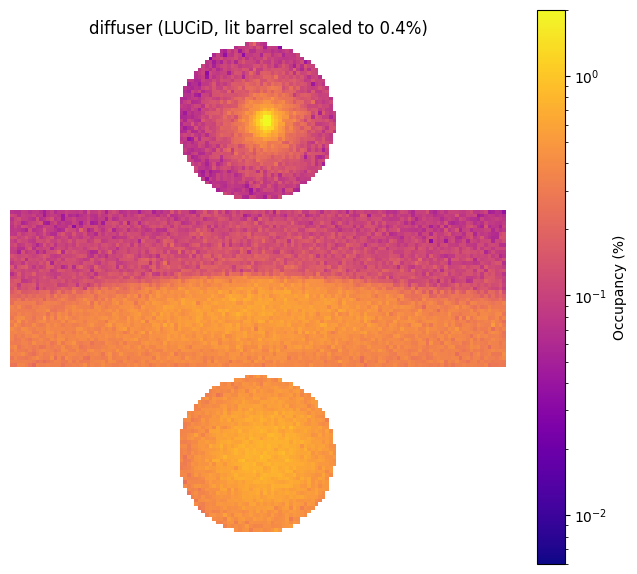

In [22]:
show_occupancy('diffuser')